# **Importing Dependencies**

In [1]:
import os
import cv2
import glob
import keras
import random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from keras.models import Model
import matplotlib.pyplot as plt
from sklearn.utils import resample
from keras.models import load_model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import BatchNormalization,MaxPooling2D,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, precision_score, recall_score
from keras.layers import Conv2D,Dense,Dropout,GlobalAveragePooling2D,MaxPool2D
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import logging
# Set TensorFlow log level to only display errors
tf.get_logger().setLevel(logging.ERROR)

2024-06-24 14:14:21.846674: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-24 14:14:21.846781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-24 14:14:21.966819: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Loading Data**

In [2]:
data_dir='/kaggle/input/chest-xray-pneumonia/chest_xray'
paths=glob.glob(data_dir+'/*/*/*.jpeg')

In [3]:
print(f'found {len(paths)} images in the dataset')

found 5856 images in the dataset


In [4]:
df=pd.DataFrame(paths,columns=['path'])
df['label']=df['path'].apply(lambda x:x.split('/')[6].strip())
df.head()

,path,label
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


In [5]:
counts=df['label'].value_counts()
counts

label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64

# **DOWN SAMPLING**

Down Sampling is performed in cases of **Data Imbalance**. In our case, the majority instance is the *PNEUMONIA* class and the minority class is the *NORMAL* class

In [6]:
df_majority = df[df.label == 'PNEUMONIA']
df_minority = df[df.label == 'NORMAL']
# Downsample majority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,  
                                   n_samples=len(df_minority), 
                                   random_state=42)  

# Combine minority class with downsampled majority class
df = pd.concat([df_minority, df_majority_downsampled])
counts=df['label'].value_counts()
counts

label
NORMAL       1583
PNEUMONIA    1583
Name: count, dtype: int64

In [7]:
df

,path,label
8,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
9,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
10,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
11,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
12,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
...,...,...
4473,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3774,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3781,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3370,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


# **Lable Encoding**
**1:PNEUMONIA**  **0:OTHERWISE**

In [8]:
df['label'] = df['label'].apply(lambda x: '1' if x == 'PNEUMONIA' else '0')
df.head()

,path,label
8,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
9,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
10,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
11,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
12,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0


# **DATA SHUFFLING**

In [9]:
df=df.sample(frac=1.0, random_state=42)
df.head(5)

,path,label
4837,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
5603,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
568,/kaggle/input/chest-xray-pneumonia/chest_xray/...,0
1101,/kaggle/input/chest-xray-pneumonia/chest_xray/...,1
117,/kaggle/input/chest-xray-pneumonia/chest_xray/...,1


In [10]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
test_df, valid_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print("Training set shapes:", train_df.shape)
print("Validation set shapes:", valid_df.shape)
print("Testing set shapes:", test_df.shape)

Training set shapes: (2532, 2)
Validation set shapes: (317, 2)
Testing set shapes: (317, 2)


In [11]:
train_df['label'].value_counts()

label
1    1277
0    1255
Name: count, dtype: int64

In [12]:
test_df['label'].value_counts()

label
0    166
1    151
Name: count, dtype: int64

In [13]:
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path', 
    y_col='label',   
    target_size=(150, 150), 
    batch_size=32,
    class_mode='binary', 
    color_mode='rgb',
    shuffle=True
)


valid_generator = test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='path', 
    y_col='label',
    target_size=(150, 150), 
    batch_size=32,
    color_mode='rgb',
    class_mode='binary',
    shuffle=False  
)



test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path', 
    y_col='label',  
    target_size=(150, 150),  
    color_mode='rgb',
    batch_size=64,  
    class_mode='binary',
    shuffle=False  
)

Found 2532 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.


In [15]:
classes=['NORMAL','PNEUMONIA']
classes

['NORMAL', 'PNEUMONIA']

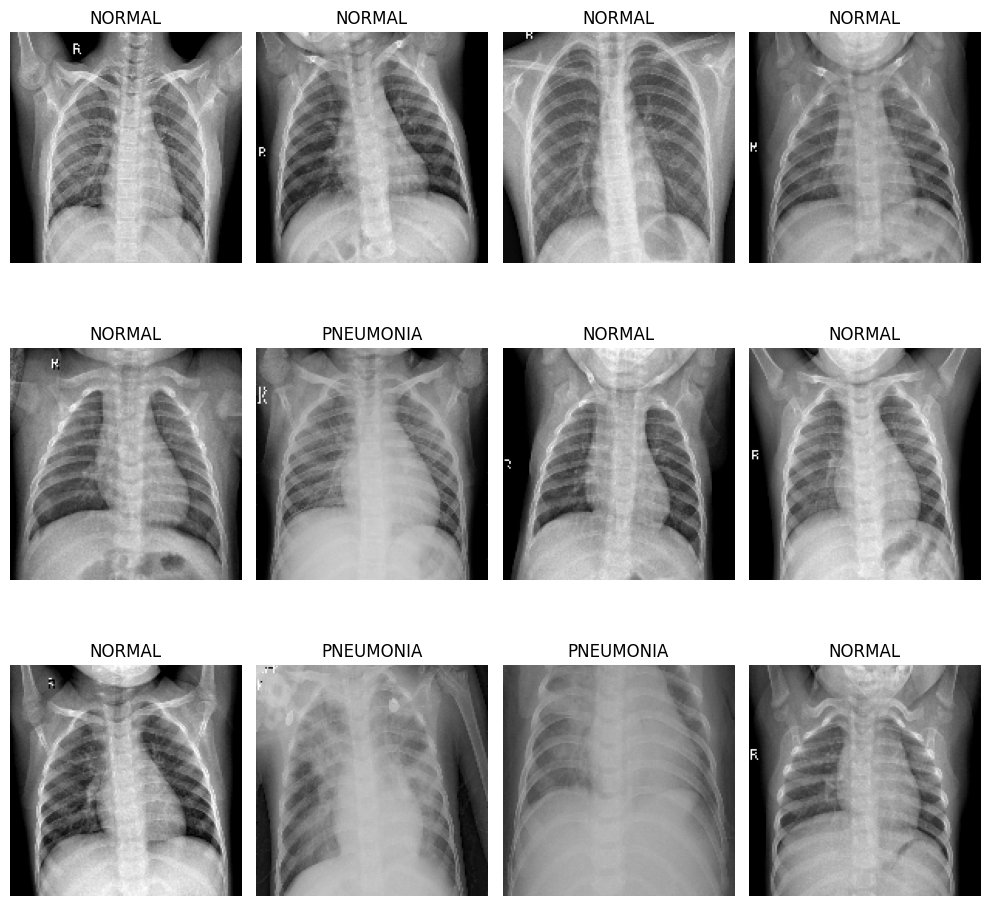

In [16]:
%matplotlib inline

batch_size = 12

images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(min(len(images), 12)):
    plt.subplot(3, 4, i + 1) 
    plt.imshow(images[i], cmap='gray')
    plt.title(f"{classes[int(labels[i])]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [17]:
train_generator.image_shape

(150, 150, 3)

In [18]:
from keras.applications import MobileNetV2
mobileNetV2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


for layer in mobileNetV2.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
mobileNet=keras.models.Sequential([
    mobileNetV2,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'), 
    Dropout(0.5),  
    Dense(1, activation='sigmoid') 
])

mobileNet.add(Dense(1,activation='sigmoid'))
mobileNet.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
mobileNet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ ?                      │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
weight_path = "cnn_weights.best.weights.h5"

checkpoint = ModelCheckpoint(weight_path, monitor='val_accuracy', verbose=1, 
                             save_best_only=True, mode='max', save_weights_only=True)

early = EarlyStopping(monitor="val_accuracy", 
                      mode="max", 
                      patience=5)

callbacks_list = [checkpoint, early]

In [21]:
mobileNet_history=mobileNet.fit(train_generator,epochs=5,validation_data=valid_generator,callbacks=callbacks_list)

Epoch 1/5
 1/80 ━━━━━━━━━━━━━━━━━━━━ 22:24 17s/step - accuracy: 0.5625 - loss: 0.6871

I0000 00:00:1719238498.966952      71 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


77/80 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy: 0.7129 - loss: 0.6749
Epoch 1: val_accuracy improved from -inf to 0.90221, saving model to cnn_weights.best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 71s 686ms/step - accuracy: 0.7183 - loss: 0.6744 - val_accuracy: 0.9022 - val_loss: 0.6501
Epoch 2/5
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8998 - loss: 0.6503
Epoch 2: val_accuracy improved from 0.90221 to 0.93375, saving model to cnn_weights.best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 348ms/step - accuracy: 0.9005 - loss: 0.6501 - val_accuracy: 0.9338 - val_loss: 0.6314
Epoch 3/5
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9096 - loss: 0.6327
Epoch 3: val_accuracy improved from 0.93375 to 0.95268, saving model to cnn_weights.best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 343ms/step - accuracy: 0.9097 - loss: 0.6325 - val_accuracy: 0.9527 - val_loss: 0.6148
Epoch 4/5
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9300 - loss: 0.6168
Epoch 4: val_accura

In [22]:
mobileNet.load_weights(weight_path)

In [23]:
evaluation_result = mobileNet.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9346 - loss: 0.6167


In [24]:
print("Test Loss:", evaluation_result[0])

Test Loss: 0.6188681721687317


In [25]:
print("Test Accuracy:", evaluation_result[1])

Test Accuracy: 0.921135663986206


In [26]:
y_pred = mobileNet.predict(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


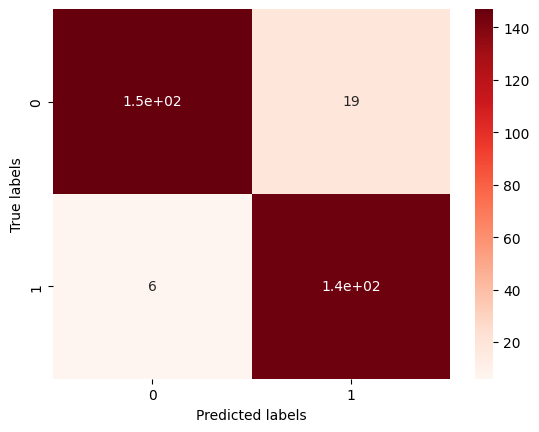

In [27]:
y_pred_binary = np.squeeze(np.round(y_pred))

confusion_Matrix = confusion_matrix(test_generator.classes, y_pred_binary)
confusion_Matrix

sns.heatmap(confusion_Matrix, annot=True, cmap='Reds')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

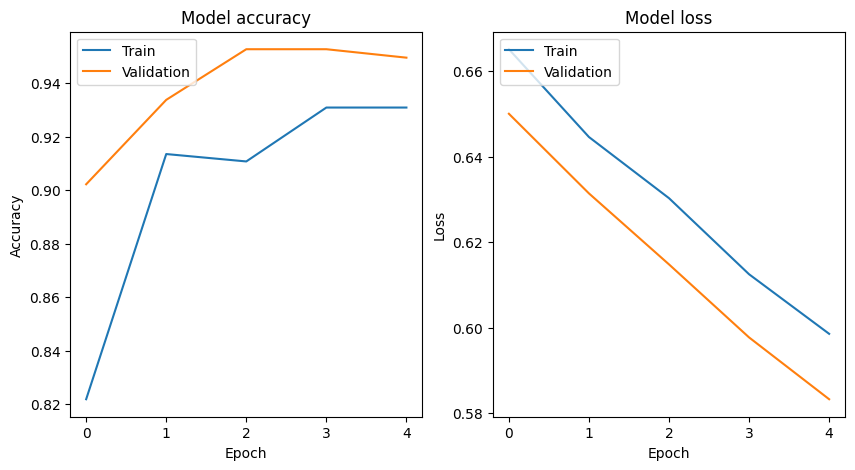

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(mobileNet_history.history['accuracy'])
ax1.plot(mobileNet_history.history['val_accuracy'])
ax1.set_title('Model accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')


ax2.plot(mobileNet_history.history['loss'])
ax2.plot(mobileNet_history.history['val_loss'])
ax2.set_title('Model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

# Display the plots
plt.show()

In [29]:
mobilenet_pred_binary = np.squeeze(np.round(y_pred))
print(classification_report(test_generator.classes, mobilenet_pred_binary))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       166
           1       0.88      0.96      0.92       151

    accuracy                           0.92       317
   macro avg       0.92      0.92      0.92       317
weighted avg       0.92      0.92      0.92       317



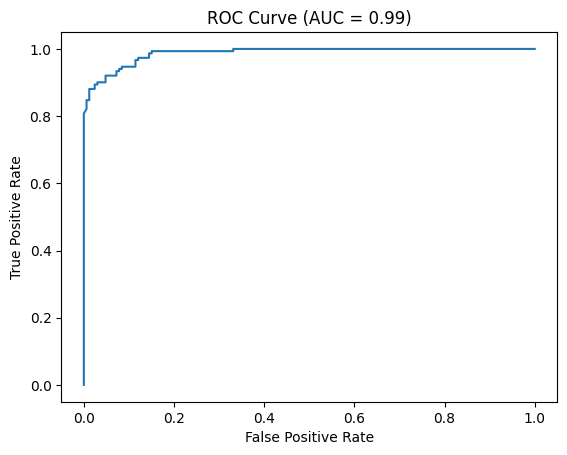

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score



fpr, tpr, thresholds = roc_curve(test_generator.classes, y_pred)


auc_score = roc_auc_score(test_generator.classes, y_pred)


import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc_score:.2f})')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


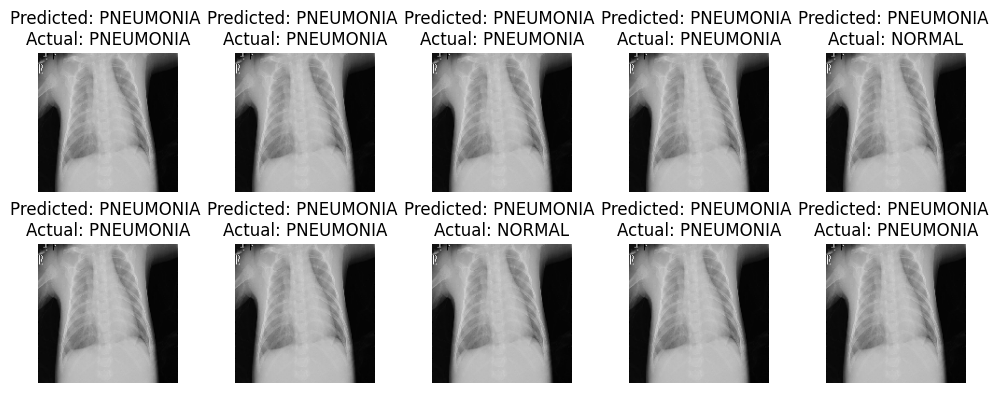

In [31]:
x_test,y_test=next(test_generator)
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
axs = axs.flatten()

for i in range(10):
    predicted = mobileNet.predict(np.array([x_test[10]])) # xtest[the index of the specific image you want to visualize]
    predictedClass = int(predicted >= 0.5)
    actual = int(y_test[i])

    axs[i].imshow(x_test[10], cmap='gray')
    axs[i].set_title(f'Predicted: {classes[predictedClass]} \nActual: {classes[actual]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [32]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained ResNet50 model without top (fully connected layers)
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze all layers in the base ResNet model
for layer in base_resnet.layers:
    layer.trainable = False

# Adding custom top layers for your specific task
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Creating the final model
resnet_model = Model(inputs=base_resnet.input, outputs=predictions)

# Compile the model
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [33]:
weight_path = "resnet_weights.best.weights.h5"

checkpoint = ModelCheckpoint(weight_path, monitor='val_accuracy', verbose=1, 
                             save_best_only=True, mode='max', save_weights_only=True)

early = EarlyStopping(monitor="val_accuracy", 
                      mode="max", 
                      patience=30)

callbacks_list = [checkpoint, early]

In [34]:
ResNet_history=resnet_model.fit(train_generator,epochs=30,validation_data=valid_generator,callbacks=callbacks_list)

Epoch 1/30
 1/80 ━━━━━━━━━━━━━━━━━━━━ 19:07 15s/step - accuracy: 0.4375 - loss: 0.7567

W0000 00:00:1719238723.768465      71 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5439 - loss: 0.7038

W0000 00:00:1719238756.061947      70 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.80126, saving model to resnet_weights.best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 53s 491ms/step - accuracy: 0.5447 - loss: 0.7035 - val_accuracy: 0.8013 - val_loss: 0.6339
Epoch 2/30
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.6633 - loss: 0.6310
Epoch 2: val_accuracy did not improve from 0.80126
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.6643 - loss: 0.6306 - val_accuracy: 0.5899 - val_loss: 0.6037
Epoch 3/30
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.6839 - loss: 0.5797
Epoch 3: val_accuracy improved from 0.80126 to 0.84543, saving model to resnet_weights.best.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 349ms/step - accuracy: 0.6847 - loss: 0.5793 - val_accuracy: 0.8454 - val_loss: 0.5036
Epoch 4/30
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7957 - loss: 0.5146
Epoch 4: val_accuracy did not improve from 0.84543
80/80 ━━━━━━━━━━━━━━━━━━━━ 29s 332ms/step - accuracy: 0.7956 - loss: 0.5144 - val_

In [35]:
resnet_model.load_weights(weight_path)

In [36]:
evaluation_result = resnet_model.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9029 - loss: 0.2483


W0000 00:00:1719239637.936150      71 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [37]:
print("Test Loss:", evaluation_result[0])

Test Loss: 0.2580578327178955


In [38]:
print("Test Accuracy:", evaluation_result[1])

Test Accuracy: 0.9022082090377808


In [39]:
y_pred = resnet_model.predict(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


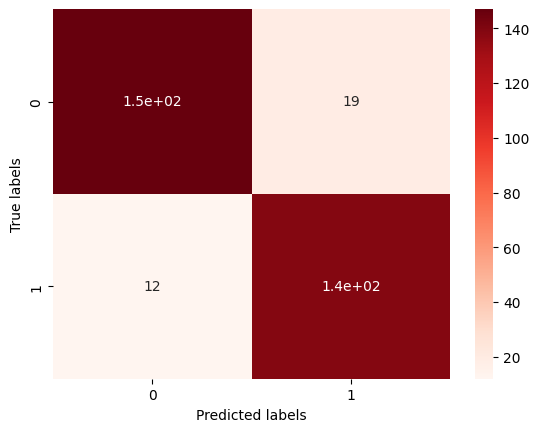

In [40]:
y_pred_binary = np.squeeze(np.round(y_pred))

confusion_Matrix = confusion_matrix(test_generator.classes, y_pred_binary)
confusion_Matrix

sns.heatmap(confusion_Matrix, annot=True, cmap='Reds')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

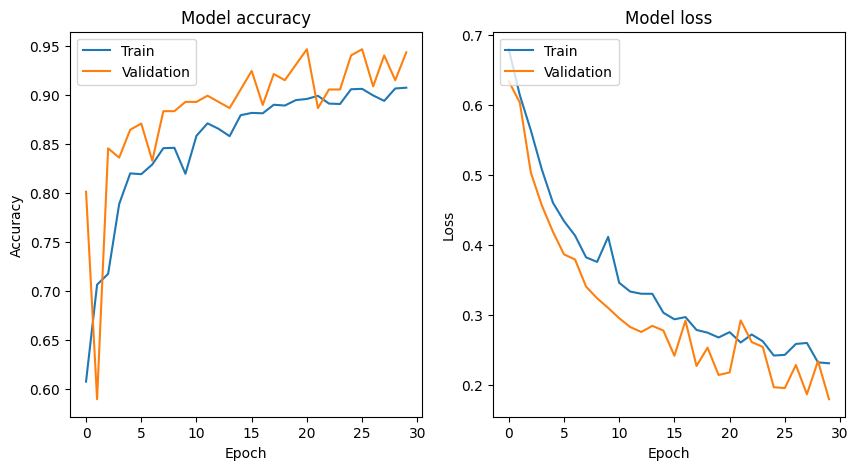

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(ResNet_history.history['accuracy'])
ax1.plot(ResNet_history.history['val_accuracy'])
ax1.set_title('Model accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')


ax2.plot(ResNet_history.history['loss'])
ax2.plot(ResNet_history.history['val_loss'])
ax2.set_title('Model loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

# Display the plots
plt.show()

In [42]:
resnet_pred_binary = np.squeeze(np.round(y_pred))
print(classification_report(test_generator.classes, resnet_pred_binary))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       166
           1       0.88      0.92      0.90       151

    accuracy                           0.90       317
   macro avg       0.90      0.90      0.90       317
weighted avg       0.90      0.90      0.90       317



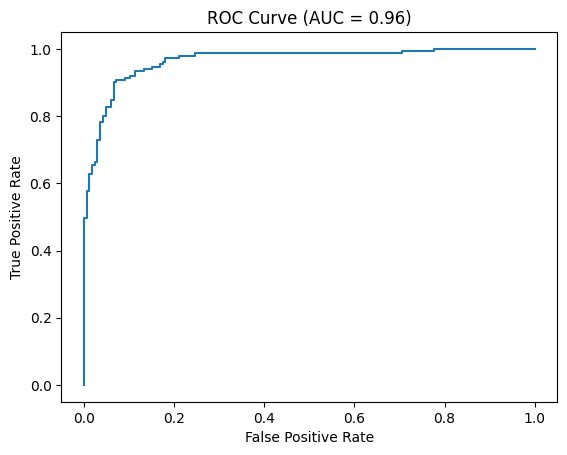

In [43]:
from sklearn.metrics import roc_curve, roc_auc_score



fpr, tpr, thresholds = roc_curve(test_generator.classes, y_pred)


auc_score = roc_auc_score(test_generator.classes, y_pred)


import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc_score:.2f})')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


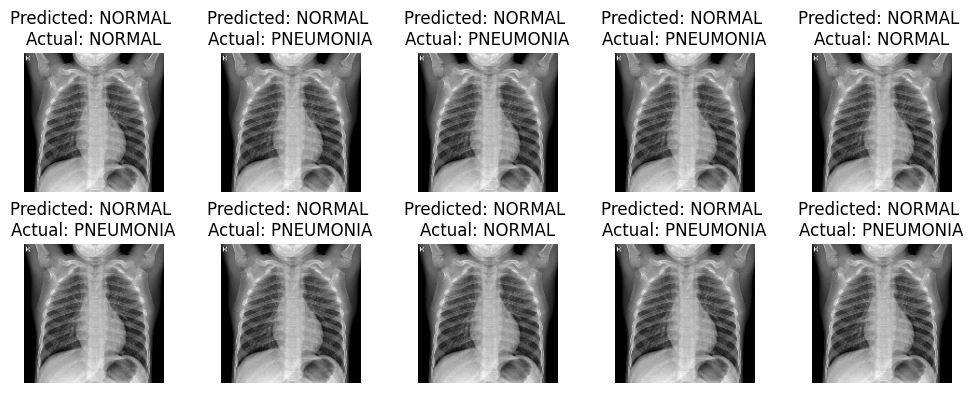

In [44]:
x_test,y_test=next(test_generator)
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
axs = axs.flatten()

for i in range(10):
    predicted = resnet_model.predict(np.array([x_test[10]])) # xtest[the index of the specific image you want to visualize]
    predictedClass = int(predicted >= 0.5)
    actual = int(y_test[i])

    axs[i].imshow(x_test[10], cmap='gray')
    axs[i].set_title(f'Predicted: {classes[predictedClass]} \nActual: {classes[actual]}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()